# Customer Churn Prediction — Exploratory Data Analysis & Data Cleaning
**Course Project — BIL 476 Data Mining (Summer 2026)**

**Dataset:** Telco Customer Churn (IBM Sample Dataset)
**Topic Area:** Classification (Topic #7 — Predictive Classification)
**Goal of this notebook:** Load the raw dataset, assess its quality, clean it, and
perform exploratory data analysis (EDA) before moving on to modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load & Inspect the Raw Data

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Data Quality Assessment

Before cleaning, we check for: missing values, duplicate records, and any
columns whose declared type doesn't match their actual content.


In [5]:
print("Null values reported by pandas:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Unique customerID count vs total rows:", df['customerID'].nunique(), "/", len(df))

# TotalCharges is stored as text (object) but should be numeric -> a red flag
blank_mask = df['TotalCharges'].str.strip() == ""
print("\nRows where TotalCharges is blank:", blank_mask.sum())
df[blank_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]


Null values reported by pandas:
0

Duplicate rows: 0
Unique customerID count vs total rows: 7043 / 7043

Rows where TotalCharges is blank: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**Observation:** pandas reports zero missing values, but that's misleading — 11
records have an empty string in `TotalCharges` instead of `NaN`. All 11 have
`tenure == 0`, meaning these are brand-new customers who haven't been billed yet.
This is a good example of a "hidden" data quality issue that a naive
`.isnull().sum()` check would miss.


## 3. Data Cleaning

In [6]:
df_clean = df.copy()

# 3.1 Fix TotalCharges: convert to numeric, coercing blanks to NaN
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Since the 11 missing rows correspond to tenure == 0 (new customers who have
# not yet been billed), the correct/justified value is 0, not the column mean.
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

# 3.2 Drop customerID: a unique identifier carries no predictive signal
df_clean = df_clean.drop(columns=['customerID'])

# 3.3 Recode SeniorCitizen (0/1) as Yes/No for consistency with other binary columns
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# 3.4 Encode the target variable as binary (kept as a separate column for clarity)
df_clean['Churn_binary'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})

print("Remaining nulls after cleaning:", df_clean.isnull().sum().sum())
print("Final shape:", df_clean.shape)
df_clean.head()


Remaining nulls after cleaning: 0
Final shape: (7043, 21)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## 4. Exploratory Data Analysis

### 4.1 Target Variable: Churn Distribution (Class Imbalance Check)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


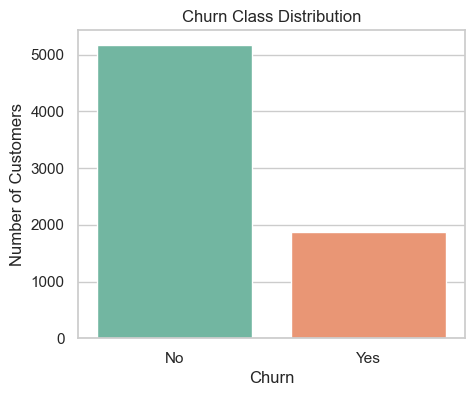

In [7]:
churn_counts = df_clean['Churn'].value_counts(normalize=True) * 100
print(churn_counts)

plt.figure(figsize=(5,4))
sns.countplot(data=df_clean, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title("Churn Class Distribution")
plt.ylabel("Number of Customers")
plt.show()


**Observation:** The dataset is imbalanced — about 73.5% of customers did not
churn vs. 26.5% who did. This will need to be accounted for later, e.g. by
using F1-score/ROC-AUC instead of accuracy alone, and possibly class weighting
or resampling (SMOTE) during modeling.

### 4.2 Numeric Features vs. Churn

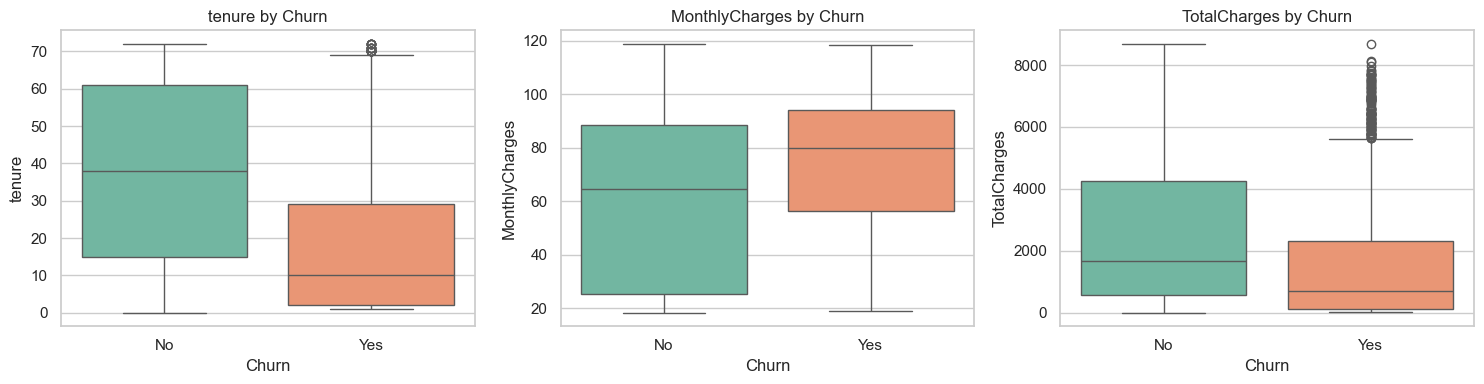

In [8]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df_clean, x='Churn', y=col, hue='Churn', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()


### 4.3 Key Categorical Features vs. Churn

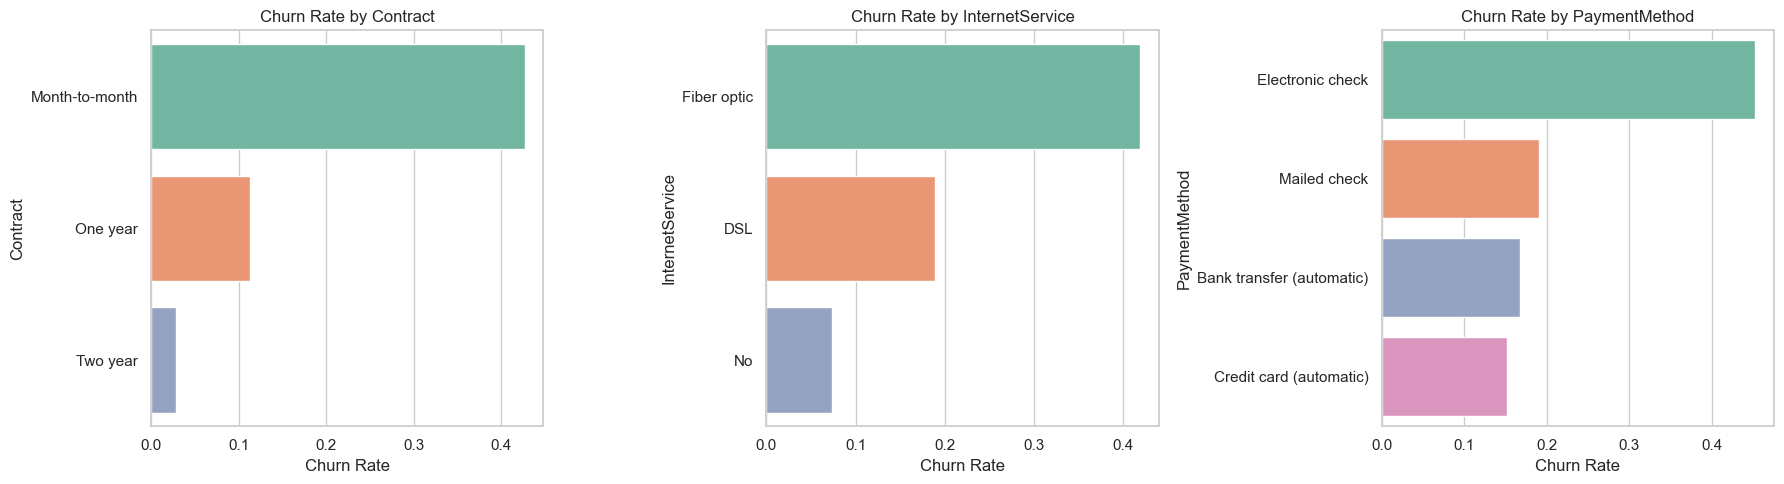

In [9]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod']
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, col in zip(axes, cat_cols):
    churn_rate = df_clean.groupby(col)['Churn_binary'].mean().sort_values(ascending=False)
    sns.barplot(x=churn_rate.values, y=churn_rate.index, hue=churn_rate.index, palette='Set2', legend=False, ax=ax)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_xlabel('Churn Rate')
plt.tight_layout()
plt.show()


**Observation:** Customers on a month-to-month contract, using fiber-optic
internet, and paying via electronic check churn at a noticeably higher rate
than other groups. These are strong candidate predictive features.

### 4.4 Correlation Among Numeric Features

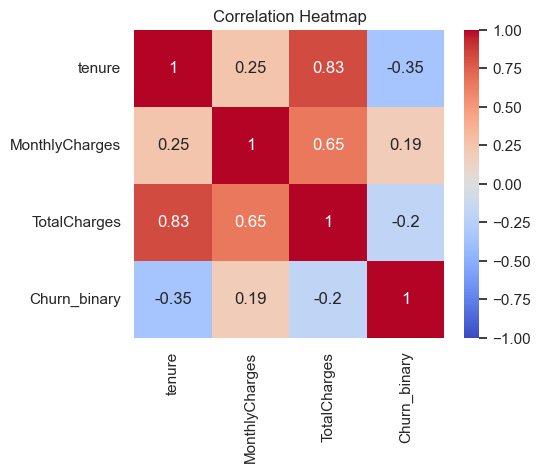

In [10]:
corr = df_clean[['tenure','MonthlyCharges','TotalCharges','Churn_binary']].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()


## 5. Save the Cleaned Dataset

This cleaned file will be the input for the preprocessing / feature-encoding
and modeling notebook (Decision Tree, Naive Bayes, k-NN, Random Forest).

In [11]:
df_clean.to_csv("../data/telco_clean.csv", index=False)
print("Saved:", df_clean.shape)


Saved: (7043, 21)
